### Project Introduction
This project analyzes an Amazon e-commerce sales dataset containing around 129k orders.
The objective is to understand sales trends, product performance, customer behavior, and shipping impact using Python and Pandas.
The analysis focuses on identifying key business insights such as top revenue states, peak sales months, cancellation rates, and category performance.

#### Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

#### Load Dataset

In [8]:
df = pd.read_csv("Amazon Sale Report.csv")
df.head()

##### The dataset contains order information such as order ID, date, product category, shipping details, order status, and revenue.

#### Data Inspection

In [4]:
df.shape

(128975, 24)

In [5]:
df.columns

Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by', 'Unnamed: 22'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  object 
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  object 
 4   Fulfilment          128975 non-null  object 
 5   Sales Channel       128975 non-null  object 
 6   ship-service-level  128975 non-null  object 
 7   Style               128975 non-null  object 
 8   SKU                 128975 non-null  object 
 9   Category            128975 non-null  object 
 10  Size                128975 non-null  object 
 11  ASIN                128975 non-null  object 
 12  Courier Status      122103 non-null  object 
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  object 
 15  Amount              121180 non-nul

In [15]:
df.isnull().sum()

Order ID                  0
Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Style                     0
SKU                       0
Category                  0
Size                      0
ASIN                      0
Courier Status         5136
Qty                       0
currency                  0
Amount                    0
ship-city                31
ship-state               31
ship-postal-code         31
ship-country             31
promotion-ids         41698
B2B                       0
fulfilled-by          83639
Year                      0
Month                     0
dtype: int64

##### The dataset contains 128,975 rows and multiple features related to orders and shipping.
##### Some columns contain missing values, especially the Amount column, which represents order revenue.

#### Data Cleaning

In [9]:
# Remove unnecessary columns
df.drop(['index','Unnamed: 22'], axis=1, inplace=True)

In [10]:
# Convert date column
df['Date'] = pd.to_datetime(df['Date'], format='%m-%d-%y')

In [11]:
# Remove rows with missing revenue
df = df.dropna(subset=['Amount'])

##### Since the Amount column represents revenue, rows with missing values were removed to ensure accurate sales analysis.

In [36]:
total_revenue = df['Amount'].sum()
total_orders = df['Order ID'].nunique()
avg_order_value = df['Amount'].mean()

print("Total Revenue:", total_revenue)
print("Total Orders:", total_orders)
print("Average Order Value:", avg_order_value)

Total Revenue: 78592678.29999998
Total Orders: 113030
Average Order Value: 648.5614647631621


#### Top 10 Products

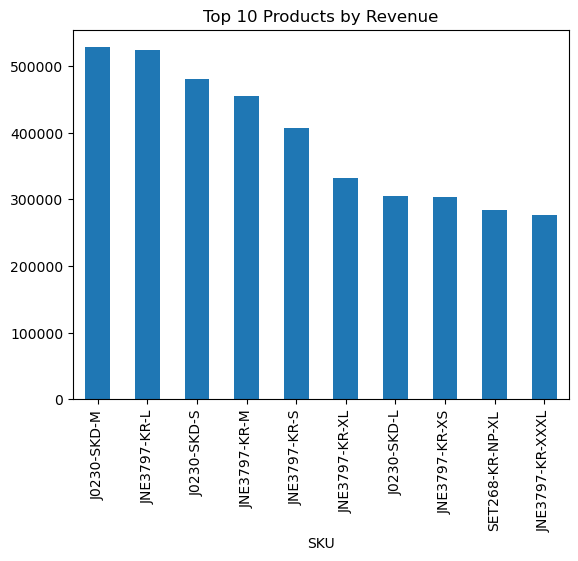

In [37]:
# This shows product performance, which businesses care about a lot.
top_products = df.groupby('SKU')['Amount'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar')
plt.title("Top 10 Products by Revenue")
plt.show()

The top-performing products contribute significantly to total revenue, suggesting that focusing on high-demand SKUs can increase profitability.

#### City-Level Analysis

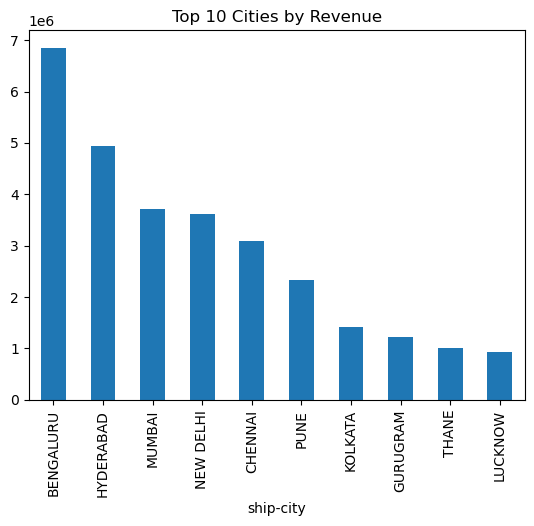

In [38]:
top_cities = df.groupby('ship-city')['Amount'].sum().sort_values(ascending=False).head(10)

top_cities.plot(kind='bar')
plt.title("Top 10 Cities by Revenue")
plt.show()

Major metropolitan cities contribute the majority of revenue, highlighting the importance of urban markets in e-commerce sales.

#### Feature Engineering

In [12]:
# Create time features.
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

##### Additional time-based features were created to analyze monthly sales trends.

#### Exploratory Data Analysis

In [13]:
# Total Revenue
df['Amount'].sum()

78592678.29999998

##### The dataset represents approximately ₹78M in total revenue.

In [19]:
#df.groupby('Category')['Amount'].value_counts().sort_values(ascending=False).head(10)

#### Monthly Sales Trend

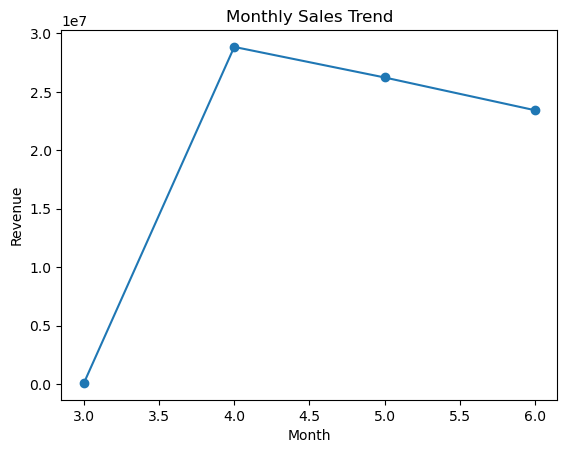

In [21]:
monthly_sales = df.groupby('Month')['Amount'].sum()

monthly_sales.plot(kind='line', marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

##### Sales peaked in April, generating approximately ₹25.6M, indicating strong seasonal demand.

#### Top States by Revenue

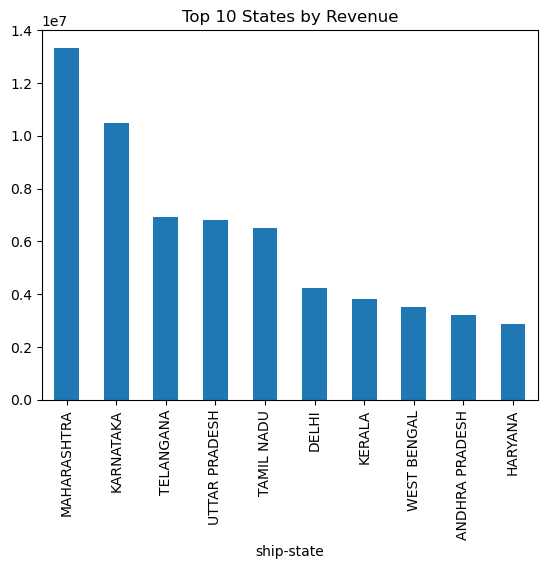

In [22]:
state_sales = df.groupby('ship-state')['Amount'].sum().sort_values(ascending=False).head(10)

state_sales.plot(kind='bar')
plt.title("Top 10 States by Revenue")
plt.show()

##### Maharashtra generated the highest revenue, followed by other major states with strong e-commerce demand.

#### Category Performance

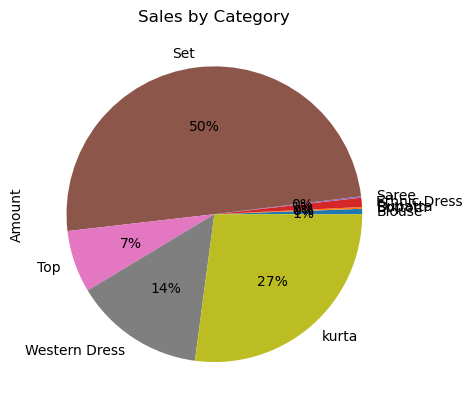

In [30]:
category_sales = df.groupby('Category')['Amount'].sum()

category_sales.plot(kind='pie', autopct='%1.0f%%')
plt.title("Sales by Category")
plt.show()

##### The Set category dominates sales, contributing the largest share of revenue.

#### Shipping Analysis

In [31]:
df.groupby('ship-service-level')['Amount'].sum()

ship-service-level
Expedited    54285183.0
Standard     24307495.3
Name: Amount, dtype: float64

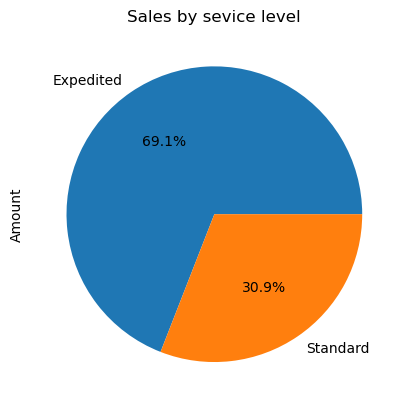

In [32]:
service_level = df.groupby('ship-service-level')['Amount'].sum()

service_level.plot(kind='pie', autopct='%1.1f%%')
plt.title("Sales by sevice level")
plt.show()

##### Expedited shipping accounts for nearly 70% of total revenue, suggesting customers strongly prefer faster delivery options.

#### Order Status Analysis

In [33]:
df['Status'].value_counts()

Status
Shipped                          77596
Shipped - Delivered to Buyer     28761
Cancelled                        10766
Shipped - Returned to Seller      1950
Shipped - Picked Up                973
Pending                            656
Pending - Waiting for Pick Up      281
Shipped - Returning to Seller      145
Shipped - Out for Delivery          35
Shipped - Rejected by Buyer         11
Shipped - Lost in Transit            5
Shipped - Damaged                    1
Name: count, dtype: int64

##### Approximately 8.8% of orders were cancelled, highlighting potential operational inefficiencies or customer behavior patterns.

#### B2B vs B2C Revenue

In [34]:
df.groupby('B2B')['Amount'].sum()

B2B
False    78001457.51
True       591220.79
Name: Amount, dtype: float64

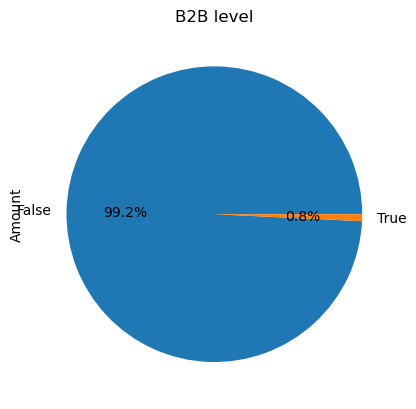

In [35]:
b2b_revenue = df.groupby('B2B')['Amount'].sum()

b2b_revenue.plot(kind='pie', autopct='%1.1f%%')
plt.title("B2B level")
plt.show()

##### The business is primarily B2C, with B2B contributing less than 1% of total revenue.

### Final Business Insights
<h5> Maharashtra generates the highest revenue.<br>
Sales peaked in April.<br>
Cancellation rate is approximately 8.8%.<br>
The Set category dominates product sales.<br>
Expedited shipping contributes ~73% of revenue.<br>
The business is heavily B2C-focused.</h5>

#### Conclusion
This analysis provides insights into sales performance, customer preferences, and operational patterns.
Businesses can leverage these insights to optimize inventory planning, improve delivery services, and reduce cancellation rates.